## Digit Recognition

In [ ]:
from DeepLearning import NN
from DeepLearning.NN import Dense, SGD, ReLU, Softmax, CategoricalCrossEntropy, Conv2D, MaxPooling, Flatten
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from PIL import Image, ImageDraw

In [13]:
train_data = pd.read_csv('./Datasets/Digit-Recognizer/train.csv')
print("Shape of train_data:", train_data.shape)

Shape of train_data: (42000, 785)


In [19]:
x = train_data.iloc[:, 1:]  
y = train_data.iloc[:, 0] 
print("Shape of X after separating features:", x.shape)
print("Shape of Y after separating features:", y.shape)

Shape of X after separating features: (42000, 784)
Shape of Y after separating features: (42000,)


In [20]:
x = x / 255.0
x = np.array(x)
x = x.reshape(42000,1,28,28)

x_train = x[:30000]
x_valid = x[30000:]
print("Shape of x:", x_train.shape, x_valid.shape)

y = np.eye(10)[y]

y_train = y[:30000]
y_valid = y[30000:]
print("Shape of y after one-hot encoding:", y_train.shape, y_valid.shape)

Shape of x: (30000, 1, 28, 28) (12000, 1, 28, 28)
Shape of y after one-hot encoding: (30000, 10) (12000, 10)


In [21]:
model = NN.Model(
    layers = [
        Conv2D(num_kernel = 32, kernel_size = (5, 5), input_shape = (BATCH_SIZE, 1, 28, 28), activation = ReLU()),
        MaxPooling(kernel_size = (2, 2), stride = 2),
        Conv2D(num_kernel = 16, kernel_size = (5, 5), input_shape = (BATCH_SIZE, 32, 12, 12), activation = ReLU()),
        MaxPooling(kernel_size = (2, 2), stride = 2),
        Flatten(),
        Dense(256, 128, activation = ReLU()),
        Dense(128, 10, activation = ReLU()),
        Dense(10, 10, activation = Softmax())
    ],
    loss_function = CategoricalCrossEntropy(),
    optimizer = SGD()
)

In [22]:
BATCH_SIZE = 128
loss_value = model.fit(x_train, y_train, BATCH_SIZE, epochs = 10, x_validation = x_valid, y_validation = y_valid)
xpoints = np.arange(0,loss_value.shape[0])
ypoints = loss_value

Epochs: 1/10    loss_value: 2.302535795153045     validation: 0.10566666666666667


KeyboardInterrupt: 

In [ ]:
print(loss_value)

[0.41907248 0.30295845 0.24299954 0.20373936 0.1798159  0.16362863
 0.14971    0.13075688 0.11297889 0.09806496]


Text(0, 0.5, 'loss Label')

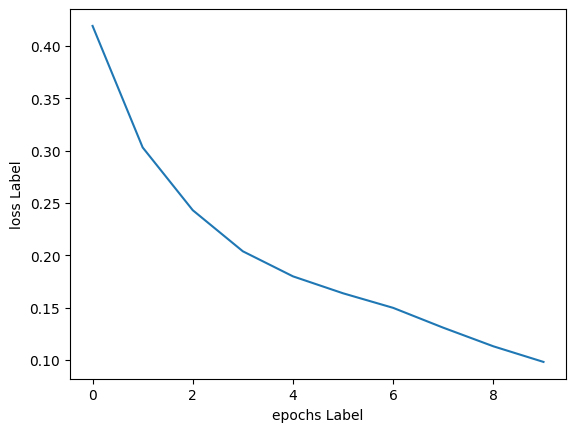

In [ ]:
plt.plot(xpoints, ypoints)
plt.xlabel("epochs Label")
plt.ylabel("loss Label")


In [ ]:
model.save("digit_recognizer")

Model saved to digit_recognizer


In [ ]:
model.load("digit_recognizer")

class PaintApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Digit Recognizer")

        # Drawing canvas (280x280)
        self.canvas = tk.Canvas(root, width=280, height=280, bg='white')
        self.canvas.pack()

        # Label to display result
        self.res_label = tk.Label(root, text="Prediction: None", font=("Helvetica", 18), fg="blue")
        self.res_label.pack(pady=10)

        # PIL image for internal storage
        self.image = Image.new("RGB", (280, 280), "white")
        self.draw = ImageDraw.Draw(self.image)

        # Event binding
        self.canvas.bind("<B1-Motion>", self.paint)
        
        # Controls
        self.btn_clear = tk.Button(root, text="Clear", command=self.clear)
        self.btn_clear.pack(side=tk.LEFT, padx=10)
        
        self.btn_predict = tk.Button(root, text="Predict Digit", command=self.predict_digit)
        self.btn_predict.pack(side=tk.LEFT, padx=10)

    def paint(self, event):
        x1, y1 = (event.x - 8), (event.y - 8)
        x2, y2 = (event.x + 8), (event.y + 8)
        self.canvas.create_oval(x1, y1, x2, y2, fill="black", outline="black")
        self.draw.ellipse([x1, y1, x2, y2], fill="black", outline="black")

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("RGB", (280, 280), "white")
        self.draw = ImageDraw.Draw(self.image)
        self.res_label.config(text="Prediction: None")

    def predict_digit(self):
        # 1. Resize and Convert to Grayscale
        img_resized = self.image.resize((28, 28)).convert('L')
        
        # 2. Convert to Numpy and INVERT (MNIST is white on black)
        # 255 becomes 0, 0 becomes 255
        img_array = np.array(img_resized)
        img_array = np.invert(img_array) 
        
        # 3. Normalize to [0, 1]
        img_array = img_array / 255.0
        
        # 4. Flatten to (1, 784)
        input_data = img_array.reshape(1, 784)

        # 5. Model Inference
        # prediction will be a probability distribution (1, 10)
        prediction = model.predict(input_data)

        # 6. Update UI
        self.res_label.config(text=f"Prediction: {prediction['prediction']} ({prediction['confidence']:.1f}%)")

Model loaded from digit_recognizer


In [ ]:
root = tk.Tk()
app = PaintApp(root)
root.mainloop()